You know what to do

In [ ]:
%pip install qiskit qiskit-ibm-runtime qiskit-aer
!pip install pylatexenc matplotlib
!pip install git+https://github.com/qiskit-community/qiskit-textbook.git#subdirectory=qiskit-textbook-src

# So I heard you wanted to add numbers quantumly

*Lab 10 — Quantum Adder*


One thing that many of us who use classical computers take for granted is how hard basic arithmetic is to implement.  Well, the joke was on us, because today if we want to develop quantum algorithms, we need to think long and hard about how to do this seemingly simple thing.  We have to think so hard about it because arithmetic is based on taking two inputs and getting only one out -- something VERY not unitary.  This consequence ripples into almost any algorithm we might like to implement in math or physics, and so it is an active area of research in quantum algorithms to design quantum arithmetic.

In this lab, we will tackle:

* How to add binary numbers...the root of adding integers, floats, etc

This has been poorly modified from https://qiskit.org/textbook/ch-states/atoms-computation.html

Below is some Python code we'll need to run if we want to use the code in this page:

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

## Review of Bits

Unless we get into a wild paradigm of quantum computing where continuous variable become a reality, we will need to code in terms of <b>finite</b> quantum registers.  At present, most computers use qubits (only 2 computational basis states $|0\rangle$ and $|1\rangle$).  Thus, if we are to perform <b>integer arithmetic</b>, the first thing we will need to do is convert our integers into binary representation which can fit nicely inside of qubits.

So lets review specifically how binary and bits work. With only 0 and 1, we can represent any piece of information we want if we set the rules properly.

The obvious example is the integers we will use for the rest of this lab. In real life, I have 10 fingers and 10 toes, so I count with decimal representation 0, 1, 2, 3, 4, 5, 6, 7, 8, and 9. In this string of digits, each digit represents how many times the number contains a certain <b>power of ten</b>. For example, when you scribble down the number 1989, you are compactly writing


$$ 1000 + 900 + 80 + 9 $$

which can be written in a more useful way for imagining binary later as:


$$(0\times 10^4) + (1\times10^3) + (9\times10^2) + (8\times10^1) + (9\times10^0) $$


The binary number systems, instead of 0-9 you only get 0-1. This means using multiples of powers of two instead of 10. So in binary, the <b>very special</b> number 1989 is 11111000101.


$$ 1989  = (0 \times 2^{11})+ (1 \times 2^{10}) +(1 \times 2^9) + (1 \times 2^8) + (1 \times 2^7) \\\\ \,\,\,   + (1 \times 2^6) + (0 \times 2^5) + (0 \times 2^4) + (0 \times 2^3) + (1 \times 2^2) + (0 \times 2^1) + (1 \times 2^0) $$



In this we are expressing numbers as multiples of 2, 4, 8, 16, 32, etc. instead of 10, 100, 1000, etc.

In the next cell, can you determine the binary representation of
* 5?
* 1213?

In [3]:
# The quick way is the built-in bin(); you might also try it by hand.
print(bin(5))
print(bin(1213))

0b101
0b10010111101


This is why in classical computing we talk about 8-bit, 16-bit, and 32-bit <b>integers or doubles</b>.  This is telling us how much <b>physical memory</b> we would devote to a given variable. For example: in an n-bit `unsigned integer` register, the largest number you can store is 2^n.  

If you would like to include negative numbers, we can do this by instead using one bit to indicate sign, then the range of numbers you can store in an n-bit `signed integer` register is $-2^{n-1}\leq x \leq 2^{n-1}$.

In the next cell, you can play around with the 5-bit encoding of integers.

 <b>How large an integer can you get?</b>

In [4]:
from qiskit_textbook.widgets import binary_widget
binary_widget(nbits=5)

HTML(value='<pre>Binary   Decimal\n 00000 = 0</pre>')

Reasonable quantum computers today have about <b>~100 qubits</b>, if you wanted to add 2 integer registers together, that means <b>50 qubits</b> a piece.  

<b>In the next cell, can you compute </b>

* the largest integer available in a 50-qubit register?

* the size of a qubit register needed to store the number 1 billion

In [5]:
# largest unsigned int in a 50-qubit register
print(2**50)
# qubits needed to store 1 billion
print(np.log(1e9)/np.log(2))

1125899906842624
29.897352853986263


So what numbers did you get?

Can you use those numbers to determine <b>how many</b> qubits you need to have an <b>array of 1000 32-bit integers</b>?


In [6]:
# an array of 1000 32-bit integers
print(1000*32)

32000


"Umm, Hank!  I'm nervous," you are hopefully thinking.  "Quantum computers today have 100 qubits total, so <b>at best</b> I can compute a pretty paltry sum of vectors"




Yup!  In the day-to-day of a quantum computing researcher, this is one of the many reasons why we constantly mumble about "our precious qubits."  Unlike classical computing, in the current age of quantum computing if you want to do any algorithm you have to think about memory management very closely.

These **bit-strings** can be used to represent more than just numbers. For example, there is a way to represent "any" english text using bits with at most 8 bits using [this table](https://www.ibm.com/support/knowledgecenter/en/ssw_aix_72/com.ibm.aix.networkcomm/conversion_table.htm). Though these are arbitrary and require extensions if you want emojis or other languages characters, this is a widely agreed-upon standard.

This is how <b>all</b> information is represented in computers. Whether numbers, letters, selfies, or TikToks....its bit-strings all the way down.

Like our standard digital computers, quantum computers are based on this same basic idea. The main difference is that they use *qubits*.  

Now, I would be a bad SQMS employee to fail to mention that you didn't have to chose bits and qubits.  You could have chosen any dit with any number of states.  Early on in classical computing, people consider [trits](https://en.wikipedia.org/wiki/Ternary_computer), (physical memory with 0,1,2 accessible).  Extensions of these to qudits are presently being considered as the architecture of quantum hardware.

## Creating an Adder Circuit <a id="adder"></a>

Now let's look at how to encode different binary strings as an input on a quantum computer. For this, on a classical computer we would use a NOT gate. This is nearly the simplest operation that you can do in a computer. It flips the bit value: ```0``` becomes ```1``` and ```1``` becomes ```0```. For qubits, I hope you recognize this as an $X$ gate.

Below, try and implement the following:
* create a new 8 qubit circuit
* flip the 2nd most significant bit to a 1 (qubit number 7).  Can you convince yourself this is 128 in binary?
* perform a measurement on all the qubits
* draw the circuit

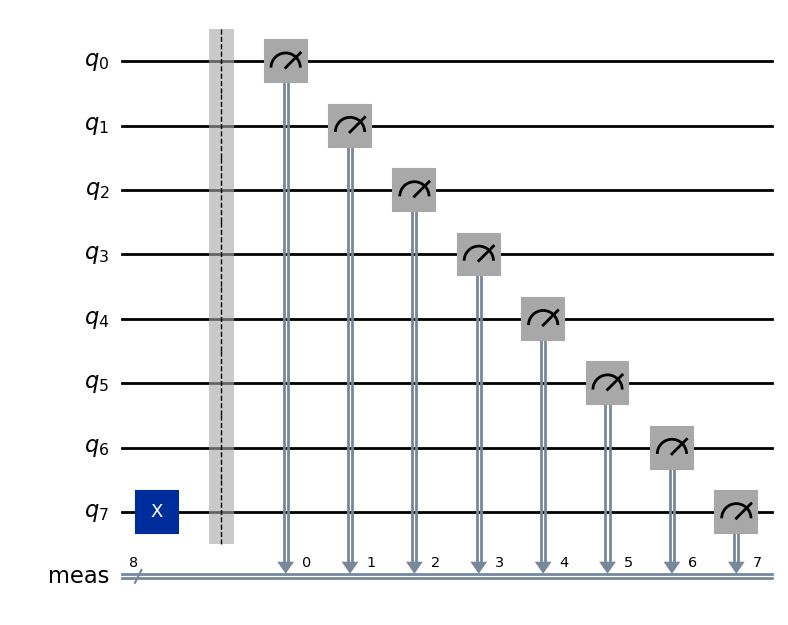

In [7]:
qc_encode = QuantumCircuit(8)
qc_encode.x(7)                 # flip qubit 7 -> 10000000 = 128
qc_encode.measure_all()
qc_encode.draw('mpl')

Now we can run the combined circuit and look at the results.

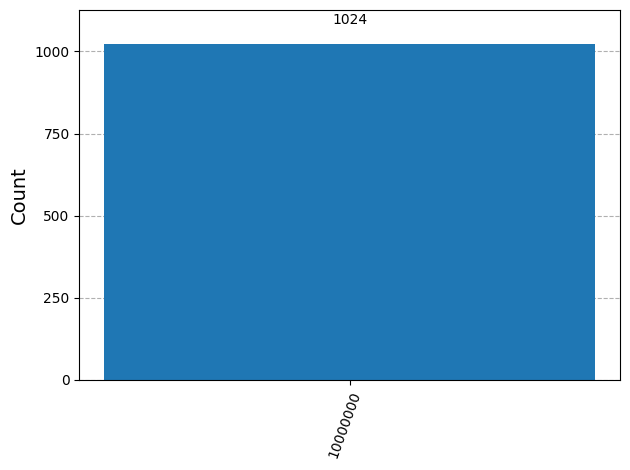

In [8]:
aer_sim = AerSimulator()
transpiled_circuit = transpile(qc_encode, aer_sim)
results = aer_sim.run(transpiled_circuit).result()
answer = results.get_counts()
plot_histogram(answer)

Now our computer outputs the string ```10000000``` instead.

The bit we flipped, which comes from qubit 7, lives on the far left of the string. This is because Qiskit numbers the bits in a string from right to left. Some prefer to number their bits the other way around, but Qiskit's system certainly has its advantages when we are using the bits to represent numbers. Specifically, it means that qubit 7 is telling us about how many $2^7$s we have in our number. So by flipping this bit, we’ve now written the number 128 in our simple 8-bit computer.

Now try out writing another number for yourself. You could do your age, for example.

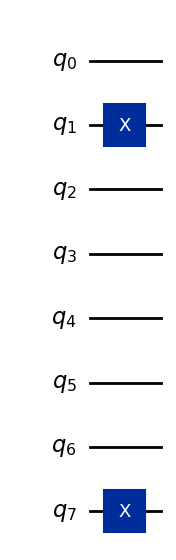

In [9]:
# encode another number (e.g. 130 = 10000010)
qc_encode = QuantumCircuit(8)
qc_encode.x(1)
qc_encode.x(7)
qc_encode.draw('mpl')

Hopefully, at this point you are starting to feel comfortable with binary and qubits.  

In the next cell, can you make a function that:
* takes in a number in decimal and qubit number
* checks if the binary representation of the number will fit into a register with a size given by your qubit number, and if it can't returns an error
* otherwise, returns a gate that sets an initial state of $|0\rangle^{\otimes n}$ to the binary representation of your number

I would test your code on a few numbers to convince yourself it works.  You might use the random integer package -- *but you will need to import that package*

In [10]:
def single_number(a, nq):
    na = int(np.log(a)/np.log(2)) + 1
    if na > nq:
        raise Exception("Your number is too big")

    qc = QuantumCircuit(nq)
    array = [int(d) for d in str(bin(a))[2:]][::-1]   # little-endian bits
    print(bin(a))
    for i in range(len(array)):
        if array[i] == 1:
            qc.x(i)
    U_num = qc.to_gate()
    U_num.name = "U$_{num}$"
    return U_num

0b1111


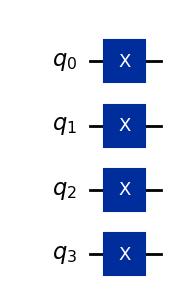

In [11]:
qc = QuantumCircuit(4)
qc.append(single_number(15, 4), [0, 1, 2, 3])
qc.decompose().draw('mpl')

Great!  But for a quantum computer, we don't really want to have just a single, classical bit string in our registers.  Instead, we would like superpositions.

Can you write a function that:
* Takes 2 decimal numbers, `a` and `b` and a number of qubits
* Checks if both binary representations will fit in the register of size corresponding to the number of qubits
* Checks if the sum of them will also fit
* If both checks succeed, return a gate that initializes the state of $\frac{1}{\sqrt{2}}(|a\rangle + |b\rangle)$ from all zero state.

0b110
0b11


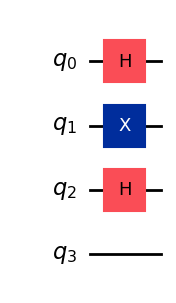

In [12]:
def two_numbers(a, b, nq):
    na = int(np.log(a)/np.log(2)) + 1
    nb = int(np.log(b)/np.log(2)) + 1
    nc = int(np.log(a+b)/np.log(2)) + 1
    if na > nq:
        raise Exception("Your number a is too big")
    if nb > nq:
        raise Exception("Your number b is too big")
    if nc > nq:
        raise Exception("Your sum a+b would be too big")

    a_array = np.array([int(d) for d in str(format(a, '#0{}b'.format(nq + 2)))[2:]][::-1])
    b_array = np.array([int(d) for d in str(format(b, '#0{}b'.format(nq + 2)))[2:]][::-1])
    c_array = np.add(a_array, b_array)

    print(bin(a)); print(bin(b))

    qc = QuantumCircuit(nq)
    for i in range(len(c_array)):
        if c_array[i] == 1:
            qc.h(i)
        if c_array[i] == 2:
            qc.x(i)
    U_num = qc.to_gate()
    U_num.name = "U$_{num}$"
    return U_num

qc = QuantumCircuit(4)
qc.append(two_numbers(6, 3, 4), [0, 1, 2, 3])
qc.decompose().draw('mpl')

Now we know how to encode information in a computer. The next step is to process it: To take an input that we have encoded, and turn it into an output that we need.

### Remembering how to add <a id="remembering-add"></a>

To look at turning inputs into outputs, we need a problem to solve. As I've told you, addition is actually problematic for quantum computers -- because addition is not typically done in such a way that it is a unitary operation on your registers.  But before we get there, lets review how large mathematical problems are done and break them down into manageable pieces. For example, how would you go about solving the following?

```
   9213
+  1854
=  ????
```

One way is to do it digit by digit, from right to left. So we start with 3+4
```
   9213
+  1854
=  ???7
```

And then 1+5
```
   9213
+  1854
=  ??67
```

Then we have 2+8=10. Since this is a two digit answer, we need to carry the one over to the next column.

```
   9213
+  1854
=  ?067
   ¹
```

Finally we have 9+1+1=11, and get our answer

```
   9213
+  1854
= 11067
   ¹
```

This may just be simple addition, but it demonstrates the principles behind all algorithms. Whether the algorithm is designed to solve mathematical problems or process text or images, we always break big tasks down into small and simple steps.

Also, notice that if we had worked with two **strictly** 4 decimal registers, we would have ran into a problem because the final answer only fits into 5 decimal registers.  This is an *overflow* error and is something that can occur if you aren't careful programming.

To run on a computer, algorithms need to be compiled down to the smallest and simplest steps possible. To see what these look like, let’s do the above addition problem again but in binary.


```
   10001111111101
+  00011100111110
                                    
=  ??????????????
```

Note that the second number has a bunch of extra 0s on the left. This just serves to make the two strings the same length.

Our first task is to do the 1+0 for the column on the right. In binary, as in any number system, the answer is 1. We get the same result for the 0+1 of the second column.

```
   10001111111101
+  00011100111110

=  ????????????11
```

Next, we have 1+1. As you’ll surely be aware, 1+1=2. In binary, the number 2 is written ```10```, and so requires two bits. This means that we need to carry the 1, just as we would for the number 10 in decimal.

```
   10001111111101
+  00011100111110
=  ???????????011
             ¹
```

The next column now requires us to calculate ```1+1+1```. This means adding three numbers together, so things are getting complicated for our computer. But we can still compile it down to simpler operations, and do it in a way that only ever requires us to add two bits together. For this, we can start with just the first two 1s.

```
   1
+  1
= 10
```

Now we need to add this ```10``` to the final ```1``` , which can be done using our usual method of going through the columns.

```
  10
+ 01
= 11
```

The final answer is ```11``` (also known as 3).

Now we can get back to the rest of the problem. With the answer of  ```11```, we have another carry bit.

```
   10001111111101
+  00011100111110
=  ??????????1011
            ¹¹
```

So now we have another 1+1+1 to do. But we already know how to do that, so it’s not a big deal.

In fact, everything left so far is something we already know how to do. This is because, if you break everything down into adding just two bits, there are only four possible things you’ll ever need to calculate. Here are the four basic sums (we’ll write all the answers with two bits to be consistent).

```
0+0 = 00 (in decimal, this is 0+0=0)
0+1 = 01 (in decimal, this is 0+1=1)
1+0 = 01 (in decimal, this is 1+0=1)
1+1 = 10 (in decimal, this is 1+1=2)
```

This is called a *half adder*. If our computer can implement this, and if it can chain many of them together, it can add anything.

### Adding with Qiskit

Let's make our own half adder using Qiskit. This will include a part of the circuit that encodes the input, a part that executes the algorithm, and a part that extracts the result. The first part will need to be changed whenever we want to use a new input, but the rest will always remain the same.

The two bits we want to add are encoded should be the **qubits 0 and 1** of a new circuit.

The result will be a string of two bits, which we will read out from the **qubits 2 and 3** and store in **classical bits 0 and 1**, respectively.

All that remains is to fill in the actual program.


The basic operations of computing are known as logic gates. We’ve already used the NOT gate, but this is not enough to make our half adder. We could only use it to manually write out the answers. Since we want the computer to do the actual computing for us, we’ll need some more powerful gates.

To see what we need, let’s take another look at what our half adder needs to do.

```
0+0 = 00
0+1 = 01
1+0 = 01
1+1 = 10
```

**In the next cell, fill out the table of expected values for each input**

Look at the result qubits?  Can you interpret each of the result qubits in terms of a simple operation?


| Input 1 | Input 2 | Result 1 (carry) | Result 2 (sum) |
|:-------:|:-------:|:----------------:|:--------------:|
| 0       | 0       | 0                | 0              |
| 0       | 1       | 0                | 1              |
| 1       | 0       | 0                | 1              |
| 1       | 1       | 1                | 0              |


If we look at the second bit, to get this part of our solution correct, we need something that can figure out whether two bits are different or not. Traditionally, in the study of digital computation, this is called an XOR gate (exclusive OR gate).

In quantum computers, the gate that does the same job as XOR gate is done by the CNOT...but whereas the XOR can return an output without changing the two inputs, the CNOT must be a unitary operator, and thus returns qubit 1 and qubit 2, with 2 being changed to match the result of the XOR.

In the next cell, write a **circuit for different two qubit inputs that returns the the XOR result in the second qubit**.  Perform measurements with the simulator to confirm it worked.

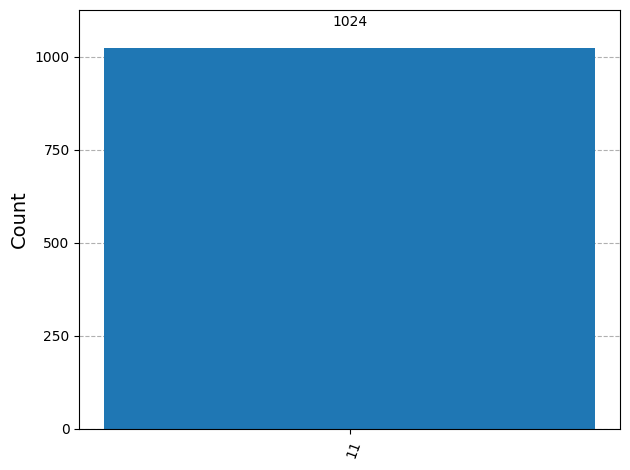

In [13]:
qc = QuantumCircuit(2, 2)
qc.x(0)
qc.cx(0, 1)        # XOR of the two inputs is written on qubit 1
qc.measure(0, 0)
qc.measure(1, 1)

backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
transpiled_circuit = pm.run(qc)
options = {"simulator": {"seed_simulator": 22}}
sampler = Sampler(mode=backend, options=options)
result = sampler.run([transpiled_circuit]).result()
plot_histogram(result[0].data.c.get_counts())

Here is a table showing all the possible inputs and corresponding outputs of the CNOT gate:

| Input (q1 q0) | Output (q1 q0) |
|:-------------:|:--------------:|
| 00            | 00             |
| 01            | 11             |
| 10            | 10             |
| 11            | 01             |

Notice this isn't quite the table we made before.

For our *half adder*, we don’t want to overwrite one of our inputs. Instead, we want to write the result on a different pair of qubits. For this, we can use two CNOTs.  Make a circuit that performs a CNOT with each input qubit controlling a third target qubit.

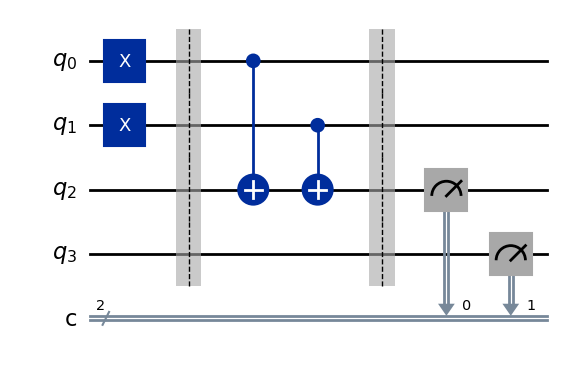

In [14]:
qc_ha = QuantumCircuit(4, 2)
# encode inputs in qubits 0 and 1
qc_ha.x(0)   # for a=1
qc_ha.x(1)   # for b=1
qc_ha.barrier()
# two CNOTs write the XOR of the inputs onto qubit 2
qc_ha.cx(0, 2)
qc_ha.cx(1, 2)
qc_ha.barrier()
# extract outputs
qc_ha.measure(2, 0)
qc_ha.measure(3, 1)
qc_ha.draw('mpl')

We are now halfway to a fully working half adder. We just have the other bit of the output left to do: the one that will live on qubit 3.

If you look again at the four possible sums, you’ll notice that there is only one case for which this is ```1``` instead of ```0```: ```1+1```=```10```. It happens only when both the bits we are adding are ```1```.

To calculate this part of the output, we could just get our computer to look at whether both of the inputs are ```1```. If they are — and only if they are — we need to do a NOT gate on qubit 3. That will flip it to the required value of ```1``` for this case only, giving us the output we need.

For this, we need a new gate: like a CNOT but controlled on two qubits instead of just one. This will perform a NOT on the target qubit only when both controls are in state ```1```. This new gate is called the *Toffoli*. For those of you who are familiar with Boolean logic gates, it is basically an AND gate.

In Qiskit, the Toffoli is represented with the `ccx` command.

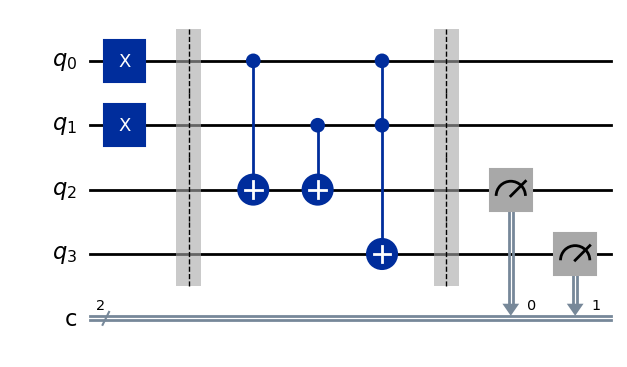

In [15]:
qc_ha = QuantumCircuit(4, 2)
# encode inputs in qubits 0 and 1
qc_ha.x(0)   # for a=1
qc_ha.x(1)   # for b=1
qc_ha.barrier()
# XOR of the inputs -> qubit 2 (the sum bit)
qc_ha.cx(0, 2)
qc_ha.cx(1, 2)
# AND of the inputs -> qubit 3 (the carry bit)
qc_ha.ccx(0, 1, 3)
qc_ha.barrier()
# extract outputs
qc_ha.measure(2, 0)   # sum (XOR)
qc_ha.measure(3, 1)   # carry (AND)
qc_ha.draw('mpl')

In this example, we are calculating ```1+1```, because the two input bits are both ```1```. Let's see what we get.

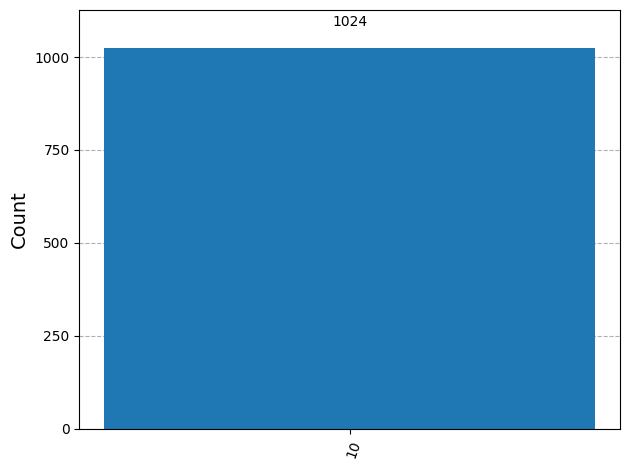

In [16]:
backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
transpiled_circuit = pm.run(qc_ha)
options = {"simulator": {"seed_simulator": 22}}
sampler = Sampler(mode=backend, options=options)
result = sampler.run([transpiled_circuit]).result()
plot_histogram(result[0].data.c.get_counts())

The result is ```10```, which is the binary representation of the number 2. We have built a computer that can solve the famous mathematical problem of 1+1!

Now you can try it out with the other three possible inputs, and show that our algorithm gives the right results for those too.

The half adder contains everything you need for addition. With the NOT, CNOT, and Toffoli gates, we can create programs that add any set of numbers of any size.

These three gates are enough to do everything else in computing too. In fact, we can even do without the CNOT. Additionally, the NOT gate is only really needed to create bits with value ```1```. The Toffoli gate is essentially the atom of mathematics. It is the simplest element, from which every other problem-solving technique can be compiled.

**If you have time, the obvious question is....how do you modify the half-adder to allow for multi-bit numbers to be added**